# Import libs

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import os
import json
from pathlib import Path
import numpy as np
import torch
from sklearn.metrics import average_precision_score
import torch.nn.functional as F

In [72]:
import numpy as np
from collections import Counter

# Your NumPy array
array = np.array([0, 1, 2, 3, 4, 5, 6, 1, 2, 3, 0, 5, 6, 4, 3, 2])

# Count occurrences of each number using Counter
count_dict = Counter(array)

# Sort the dictionary by keys
sorted_count_dict = dict(sorted(count_dict.items()))

print(sorted_count_dict)


{0: 2, 1: 2, 2: 3, 3: 3, 4: 2, 5: 2, 6: 2}


In [73]:
10 / torch.tensor([1, 2, 3, 4, 5, 6])

tensor([10.0000,  5.0000,  3.3333,  2.5000,  2.0000,  1.6667])

In [75]:
None is None

True

In [77]:
y_true = np.zeros(4096)
y_true[10:350] = 1.
y_true[800:806] = 1.
y_true[3450:3460] = 1.

y_pred = y_true.copy()
y_pred[10:350] = 0.6
y_pred[800:806] = 0.6
y_pred[3450:3460] = 0.7
y_pred[1000:1050] = 0.5 # what?????? change number

average_precision_score(y_true, y_pred)

1.0

In [71]:
x = torch.tensor(1.2345)
sigmoid_output = torch.sigmoid(x)
logits = torch.tensor([x, 0.0])
softmax_output = F.softmax(logits, dim=0)
print(sigmoid_output.item())
print(softmax_output.numpy())

0.7746052145957947
[0.7746052  0.22539477]


In [2]:
arr = np.arange(10)
np.random.shuffle(arr)

In [3]:
arr

array([7, 2, 0, 9, 5, 8, 4, 3, 6, 1])

In [4]:
torch.load('/home/jovyan/dnalm/runs/annotation_upweighted_edges_large_42k_flash_attention/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len42000_maxnsegm_10000_msz_5_bptt-1_lr5e-06_AdamW_constant_with_warmup_wd1e-04_p10000_bs64_it500000/run_1/model_best/pytorch_model.bin', map_location='cpu')

{'cls_token': tensor([1]),
 'sep_token': tensor([2]),
 'mem_token_ids': tensor([32000, 32001, 32002, 32003, 32004]),
 'model.bert.embeddings.position_ids': tensor([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
           14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
           28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
           42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
           56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
           70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
           84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
           98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
          112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
          126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
          140, 141, 142, 143, 144, 145, 146, 

# Configure model

In [3]:
os.chdir('/home/jovyan/dnalm/')

In [4]:
rmt_model_path = Path('/home/jovyan/dnalm/runs/annotation_bert_base_MANE_4k_bpe/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr2e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs64_it500000/run_1/')

In [5]:
exp_config = json.load((rmt_model_path / 'config.json').open('r')) # it should be config.json that I sent you

In [6]:
for k in ['input_seq_len', 'model_cfg', 'model_cls', 'backbone_cls', 'input_size', 'num_mem_tokens', 'max_n_segments', 'tokenizer']:
    print(f'{k}: {exp_config[k]}')

input_seq_len: 4096
model_cfg: ./data/configs/L12-H768-A12-V32k-preln-lastln.json
model_cls: src.gena_lm.modeling_rmt:RMTEncoderForTokenClassification
backbone_cls: src.gena_lm.modeling_bert:BertForTokenClassification
input_size: 512
num_mem_tokens: 5
max_n_segments: 10000
tokenizer: ./data/tokenizers/t2t_1000h_multi_32k/


In [7]:
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')

/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from src.gena_lm.modeling_bert import BertForTokenClassification

In [9]:
model_cfg = AutoConfig.from_pretrained('./data/configs/L12-H768-A12-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cfg.num_labels = 6
model_cfg.problem_type = 'multi_label_classification'
model_cls = BertForTokenClassification
model = model_cls(config=model_cfg)

In [10]:
# ckpt = torch.load(str('/home/jovyan/dnalm/runs/annotation_bert_base_MANE_4k_bpe/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr2e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs64_it500000/run_1/model_best/pytorch_model.bin'), map_location='cpu')
# model.load_state_dict(ckpt, strict=False)

In [11]:
# model.bert.base_model.embeddings.word_embeddings(torch.tensor([100]))

In [12]:
rmt_config = {
            'num_mem_tokens': exp_config['num_mem_tokens'],
            'max_n_segments': exp_config['max_n_segments'],
            'input_size': exp_config['input_size'],
            'bptt_depth': -1,
            'sum_loss': True,
            'tokenizer': tokenizer
        }
from src.gena_lm.modeling_rmt import RMTEncoderForTokenClassification
rmt_cls = RMTEncoderForTokenClassification
model = rmt_cls(model, **rmt_config)

In [13]:
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/annotation_bert_base_MANE_4k_bpe/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4096_maxnsegm_10000_msz_5_bptt-1_lr2e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs64_it500000/run_1/model_best/pytorch_model.bin'), map_location='cpu')
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!

missing: []
unexpected_k: []


In [14]:
model = model.eval()
# model.half()

In [15]:
# model.model.embeddings(torch.tensor([1]))

# Evaluation example

In [16]:
# seq = ''
# with open('/home/jovyan/dnalm/downstream_tasks/annotation/sample.fasta', 'r') as f:
#     for line in f:
#         seq += line[:-1]

In [17]:
# seq

In [18]:
seq = 'ATGC'*1234
input_features = tokenizer(seq, return_tensors='pt')

input_features['labels_mask'] = input_features['attention_mask'] # dumb realization

In [19]:
# check the length of the sequence in tokens with no PADDING (but with SEP and CLS)
# tokenizer([seq], return_tensors='pt')['input_ids'].shape

In [20]:
input_features['input_ids'].shape

torch.Size([1, 619])

In [21]:
input_features.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels_mask'])

In [22]:
input_features['labels'] = torch.randint(0, 6, (input_features['input_ids'].shape[1], 6)).unsqueeze(axis=0) # yeah, for now you must specify whatever labels, model won't work without them, it does not change the prediction
# input_features['labels'] = None

In [23]:
input_features['labels'].shape

torch.Size([1, 619, 6])

In [24]:
# with torch.autocast(device_type='cuda', dtype=torch.float16):
with torch.no_grad():
    out = model(**input_features, output_hidden_states=True)

/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/transformers/modeling_utils.py:1101: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


In [25]:
out.keys()

dict_keys(['loss', 'logits', 'hidden_states', 'loss_0', 'loss_1', 'logits_segm', 'labels_segm', 'rmt_logits_masks', 'rmt_logits_masks_segm'])

# New

In [28]:
out['hidden_states'][12].shape

torch.Size([1, 512, 768])

In [47]:
out['logits'].shape

torch.Size([1, 1024, 6])

# Old

In [118]:
out.rmt_logits_masks.shape # REMEMBER, here is the predictions for ALL tokens, including SEP, PADDING, and CLS

torch.Size([1, 3584])

In [119]:
out.rmt_logits_masks

tensor([[0., 0., 0.,  ..., 0., 0., 0.]])

In [120]:
# you can handle it like this
out.logits[:, out.rmt_logits_masks[0, :].bool(), :].shape

torch.Size([1, 3372, 6])

In [121]:
out.logits[0, 0, :] # use softmax to get probabilities

tensor([-0.2498, -0.2897, -0.0503, -0.7057, -0.7579,  0.2251])

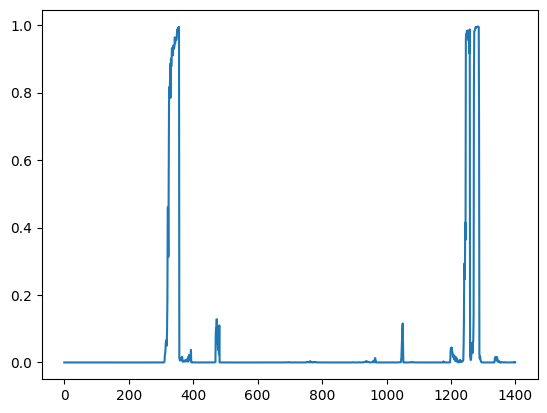

In [133]:
import matplotlib.pyplot as plt
from torch.nn.functional import sigmoid

plt.clf()
plt.plot(sigmoid(out.logits[:, out.rmt_logits_masks[0, :].bool(), :][0, :, 4][:1400]))
plt.show()

In [134]:
sigmoid(out.logits[:, out.rmt_logits_masks[0, :].bool(), :][0, :, 4][:10])

tensor([6.8392e-05, 4.8174e-05, 6.2841e-05, 3.9234e-05, 4.7705e-05, 4.8060e-05,
        4.7575e-05, 4.1978e-05, 4.6392e-05, 3.9365e-05])

In [128]:
out.logits[0, :, 4]

tensor([-0.7579, -0.4074, -0.3354,  ...,  0.5541,  0.1620, -0.6756])

In [115]:
tokenizer([seq[1:]], return_tensors='pt')['input_ids'][0, 1]

tensor(19564)

In [116]:
tokenizer.decode(19564)

'CTTG'

# Testing

In [17]:
import h5py

In [18]:
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/mane/main_transcript_train_dataset.hdf5', "r")

In [19]:
len(list(dataset_file.keys()))

32283

In [20]:
input_ids = np.array(dataset_file[f'transcript_{0}']["input_ids"])

In [21]:
input_ids

array([    1,  3948,   194, ...,   753, 10660,     2])

In [22]:
input_ids.shape

(20906,)

In [38]:
token_type_ids = np.zeros(input_ids.shape[0])
attention_mask = (input_ids != 3).astype(int)

In [45]:
input_features = {"input_ids": torch.tensor(input_ids.reshape(1, -1)),
 "token_type_ids": torch.tensor(token_type_ids.reshape(1, -1)),
 "attention_mask": torch.tensor(attention_mask.reshape(1, -1))}
input_features['labels'] = torch.randint(0, 6, (input_features['input_ids'].shape[1], 6)).unsqueeze(axis=0)

In [46]:
out = model(**input_features)

UnboundLocalError: local variable 'out' referenced before assignment